#### `Débruitage par Sobolev et régularisation de variation totale`

*Important:* Please read the [installation page](http://gpeyre.github.io/numerical-tours/installation_python/) for details about how to install the toolboxes.

- This numerical tour explores the use of variational minimization to perform denoising. 
- It consider the Sobolev and the Total Variation regularization functional (priors).

In [1]:
import sys, os

# chemin ABSOLU vers le dossier qui contient nt_toolbox
toolbox_parent = r"/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle"
sys.path.insert(0, toolbox_parent)

from nt_toolbox.general import *
from nt_toolbox.signal import *

In [2]:
from __future__ import division
import nt_toolbox as nt
#from nt_solutions import denoisingsimp_4_denoiseregul as solutions
%matplotlib inline
%reload_ext autoreload
%autoreload 2

## `I. À priori et Régularisation`
__`Pour une image`__ $f$ __`donnée`__ $J(f) \in \mathbb{R}$ __`est l’information "À PRIORI" imposée sur la forme de l’image recherchée, indépendamment des données bruitées`__ $y$. 
- formulation de l’énergie $E(f) = \frac{1}{2}\|y-f\|^2 + \lambda J(f) $
- il `combine un ajustement aux données` via une norme $L^2$  et __`l’à priori`__.
- si $J(f)$ est une fonction convexe de $f$, alors le minimum existe et il est unique. 
Le débruitage d’une image $y$ est obtenu par une minimisation variationnelle $ \min_f \frac{1}{2}\|y-f\|^2 + \lambda J(f) $ 
Si $J(f)$ est un fonction continue de l'image $f$, un minimiseur de ce problème peut être calculé par descente de gradient. 
 - Cela définit une suite d’images $f^{(\ell)}$ indexée par $\ell \in \mathbb{N}$ tel que : $ f^{(\ell+1)} = f^{(\ell)} + \tau \left( f^{(\ell)}-y + \lambda \text{Grad}J(f^{(\ell)}) \right). $
 - Notons que $f^{(\ell)}$ converge vers une solution du problème lorsque $\ell \rightarrow +\infty$
 - $\large \tau$ requiert d'être suffisamment faible, plus précisément, si la fonction $J$ est deux fois différenciable : $ \tau < \frac{2}{1 + \lambda \max_f \|D^2 J(f)\|}$
 - Le paramètre  $\tau>0$ doit être adapté au niveau de bruit, accroitre sa valeur moyenne rend le débruitage plus agressif. 

In [3]:
n = 256
path= '/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/'
name = path + 'nt_toolbox/data/hibiscus.bmp'
f0 = load_image(name, n)
print(f0.shape)
# normalise l'image, pour l’affichage et les paramètres (bruit, λ, etc.).
f0 = rescale(f0)

(256, 256)


Une image discrète pixélisée $f \in \mathbb{R}^N$ où $N=n \times n$ le nombre de pixel $\nabla f(x) \in \mathbb{R}^2$ calculé à l’aide de différences finies.
 - $J_{continue}(f) = \int \|\nabla f(x)\|^2 dx$,  est la version continue de la somme discrète de $J_{discrete}(f)≈ \sum_{i,j}||\nabla f_{i,j}||^2$
- le gradient au point $x$ et définit tel que : $\nabla f(x) = \large \left(  \frac{\partial f(x)}{\partial x_1},\frac{\partial f(x)}{\partial x_2} \right)$
- Gr = $grad(f_{TV})$ est le champ de gradients de l’image, de taille $(n,n,2)$

In [9]:
#Gr = grad(f0)
Gy, Gx = np.gradient(f0)
Gr = np.stack((Gx, Gy), axis=0).T
print(Gr.shape)

(256, 256, 2)


__`La norme euclidienne`__ $L_2$ `du gradient` $d(x) = \|\nabla f(x)\| $ `en chaque pixel` :
 -  $d(i,j)= \sqrt{(∂_x f(i,j))^2 +(∂_yf(i,j))^2}$

In [10]:
#l_2 = np.sqrt(np.sum(Gr**2, axis=2))
l_2 = np.sqrt(Gr[:,:,0]**2+Gr[:,:,1]**2)
print(f"d.shape : {l_2.shape}")

d.shape : (256, 256)


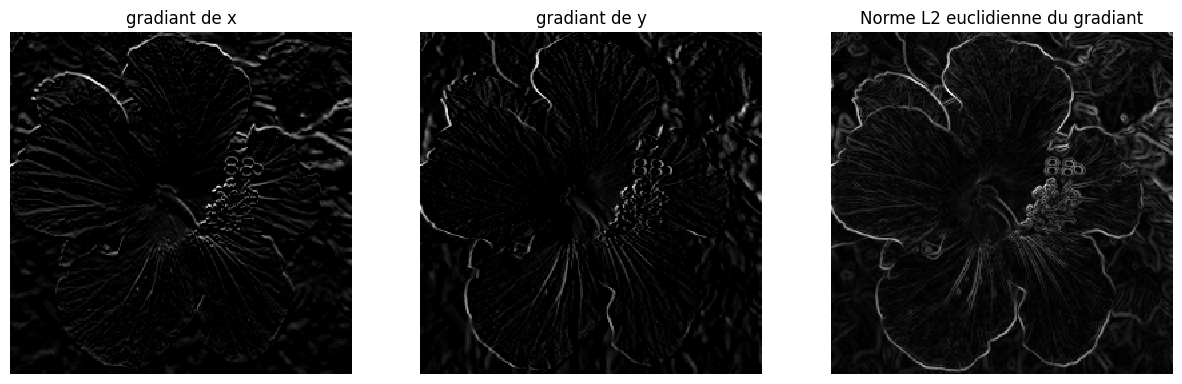

In [11]:
plt.figure(figsize=(15, 7))
imageplot(clamp(Gr[:, :,0]), 'gradiant de x', [1, 3, 1])
imageplot(clamp(Gr[:, :,1]), 'gradiant de y', [1, 3, 2])
imageplot(clamp(l_2),         'Norme L2 euclidienne du gradiant', [1, 3, 3])

### _`Deux types énergies construites à partir de`_ $L_2$, 
`J_discrete ≈ énergie TV classique, avec une norme $L_1$ sur` $|\nabla f|$
- Avec la norme locale du gradient $|\nabla f|$ à chaque pixel, on fait la somme des normes sur l’image.
`J_discrete_sobolev l’à priori d’image de Sobolev` (norme $H^1$) discrète est un à priori quadratique.
- J_discrete_sobolev prend le carré de la norme du gradient à chaque pixel 
- La norme de Sobolev est la norme $L_2$ du gradiant $\nabla f \in\mathbb{R}^{N \times 2}$

In [12]:
print(f"l2.shape : {l_2.shape} est un tableau 2D où chaque case contient la norme du gradient en ce pixel.\n")
J_disc = np.sum(l_2)
print(f"J_disc est l'énergie TV classique, avec une norme L_1 : {J_disc}\n")
J_disc_Sobolev = np.sum(l_2**2)
print(f"La vraie énergie Sobolev pour une image f est en version discrète : {J_disc_Sobolev}")

l2.shape : (256, 256) est un tableau 2D où chaque case contient la norme du gradient en ce pixel.

J_disc est l'énergie TV classique, avec une norme L_1 : 1933.6361164862008

La vraie énergie Sobolev pour une image f est en version discrète : 138.3957826153923


### __`Plus l'à priori est grand, plus l’image a de variations/bords`__

### `Débruitage, régularisation de type chaleur`
 - La régularisation de type chaleur, lisse l’image à l’aide d’un filtre passe‑bas. 
 - Augmenter la valeur de $\large ∣\sigma∣$ augmente la quantité de lissage. 
 - On ajoute du bruit à l’image originale.
    - $f_0$ image réelle 
    - $y$ image $f_0$ bruitée

`Bruit (gaussien) :`
 - Est un signal aléatoire ajouté à l'image, avec une loi de probabilité gaussienne (en général bruit blanc).
 - Contient autant de hautes que de basses fréquences, ne “filtre” rien et pollue toutes les fréquences.    

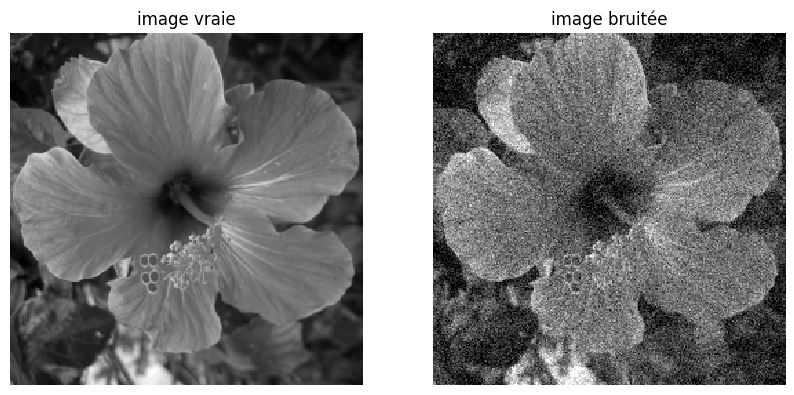

In [13]:
sigma = .1
y = f0 + np.random.randn(n, n)*sigma
plt.figure(figsize=(10, 10))
imageplot(clamp(f0),'image vraie', [1,2,1])
imageplot(clamp(y),'image bruitée', [1,2,2])

$f^{\star}$ `la régularisation de Sobolev peut-être calculé en utilisant la transformée de Fourier` : 
- La norme de Sobolev est un objet purement mathématique, la régularisation de Sobolev est l’utilisation de cette norme comme pénalité dans un problème d’optimisation (débruitage).
- $ \hat f^{\star}(\omega) = \large \frac{\hat y(\omega)}{ 1+\lambda S(\omega) } \quad$ $\text{où}\quad S(\omega)=\|\omega\|^2. $


   - montre que $f^{\star}$ est un filtre de $y$.
   - utile pour la transformée de Fourier des observations.

In [14]:
# Tranformée de Fourier d'une image bruitée 
yF = np.fft.fft2(y)

`Deux domaines : indices (pixels) vs fréquences`
 - pour un signal discret $f, f[1], … , f[n−1]$ :
 - l’index $k=0,…,n−1$ correspond à la position (pixel, temps, etc.).
 - avec la TFD on a un vecteur $\hat f, \hat f[1], … , \hat f[n−1]$, ces indices de ce vecteur sont les fréquences discrètes.

Autrement dit :
 - `Domaine spatial` $=>$ indices k.
 - `Domaine fréquentiel` $=>$ indices ω (ou ξ, etc.), qui jouent le rôle de fréquences.

`Comment on indexe les fréquences en pratique`
 - pour un signal de longueur n, pair, on représente les fréquences par des entiers $\omega∈\lbrace−\frac{n}{2},…,−1,0,1,…,\frac{n}{2}−1\rbrace$ 

`Grille de fréquences`
- table des coordonnées de chaque fréquence ($ω_x ,ω_y$) associée à un coefficient de la transformée de Fourier 2D.
`Du signal 2D aux fréquences` 
- pour une image $(n×n)$, sa transformée de Fourier 2D `yF = np.fft.fft2(y)` est un tableau $(n×n)$. 
- chaque case $y_F[i, j]$ correspond à une fréquence discrète ($ω_x ,ω_y$) que l’on obtient à partir des indices i,j.
- pour appliquer `un filtre` qui dépend de $ω$ comme $S(ω)=||ω||^2$, 
- qui est défini pour chaque pixel du spectre, donc pour chaque paire d’indices (i,j). 

In [15]:
x = y.shape[0]           # image n x n
freq = np.fft.fftfreq(x) # f \in [-0.5,0.5)
omega = 2*np.pi          # ω \in [-π, π)

`Convention d’échelle pour les fréquences : `
- np.fft.fftfreq(n) renvoie des fréquences en cycles par pixel dans l’intervalle [−0.5,0.5].
- on note les fréquences angulaires $\omega$ en radians par pixel, 
- liées par $ω=2πf$, où $f$ est en cycles/pixel,
- $(2/n)^2$ vient d’un choix de normalisation discret pour que le terme de Sobolev discret corresponde au terme continu

In [16]:
# grille 2D des fréquences (ωx, ωy)
wx, wy = np.meshgrid(freq*omega, freq*omega, indexing='ij')
# norme au carré ||ω||^2 et poids S(ω)
Sω_norm = (wx**2 + wy**2) * (2/n)**2  

_`Calculons la pénalité à priori de Sobolev (la ramener dans l’intervalle [0,1])`_
- la pénalité Sobolev $J_{Sobolev}(f) = ∫||∇f(x)||^2 dx$, est la fonction de régularisation.
- construction de la pénalité Sobolev dans le domaine de Fourier avec un filtre dépendant de $S(ω)^2 =X^2 + Y^2$
- d’où le poids fréquentiel $S(ω)=||ω||^2$
- en discret la somme des normes $L_2$ du gradient sur tous les pixels. 
- construction, dans le domaine de Fourier, du filtre associé à la pénalisation de Sobolev $∫|∇f(x)|^2dx$
- en discret, on multiplie le spectre $\hat f[\omega]$ par ce poids fréquentiel pour définir le filtre.
- L'énergie quadratique dans le domaine de Fourier, proportionnelle à $J_{Sob}(f)=\sum S(ω)\hat f |(ω)∣^2dω,$ 
- Le poids fréquentiel $S(ω)=||\omega||^2$ agit comme un filtre passe‑bas pénalisant les hautes fréquences.

`La pénalité mesure la lissité de l’image`. 
`Plus les gradients sont grands, plus la pénalité est élevée.` 

_`Effectuons le débruitage par filtrage`_
- construction de la pénalité Sobolev dans le domaine de Fourier avec un filtre dépendant de $S(ω)^2 =X^2 + Y^2$
- débruitage de l'image dans le domaine fréquentiel $\hat f^⋆(\omega)= \Large \frac{\hat y(\omega)}{1+λS(\omega)}$ avec le paramètre de `régularization lambda`

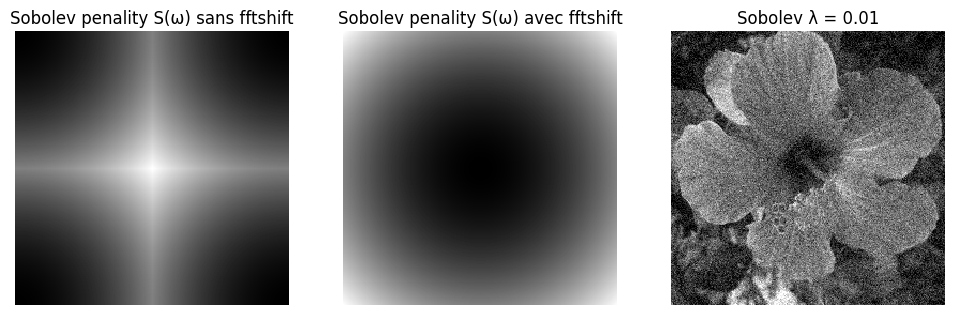

In [17]:
lambd = .01
fsob = lambda y,lambd,Sω : np.real(np.fft.ifft2(y / (1 + lambd * Sω)))
# débruitage par filtrage à l'aide de la pénalisation de Sobolev
fSob = fsob(yF,lambd, Sω_norm)

plt.figure(figsize=(12, 4))
imageplot(clamp(Sω_norm), 'Sobolev penality S(ω) sans fftshift', [1,3,1])
imageplot(clamp(np.fft.fftshift(Sω_norm)), 'Sobolev penality S(ω) avec fftshift', [1,3,2])
imageplot(clamp(fSob),f'Sobolev λ = {lambd}', [1,3,3])

### `Interprétation :`    
- zones claires les fréquences fortement pénalisées. 
- zones sombres les fréquences peu pénalisées.
- sans fftshift, les coins ≈ basses fréquences, le centre et les bords ≈ fréquences plus élevées.   
- avec fftshift on recentre les basses fréquences pour une visualisation intuitive (centre sombre).      

### _`Exercice 1`_

Caculons la solution pour plusieurs valeur de $\lambda$ et choisissons la valeur optimale de débruitage correspondant à l'à priori |fSob|. Accroitre progressivement $\lambda$ et réduire le nombre d'itérations. 

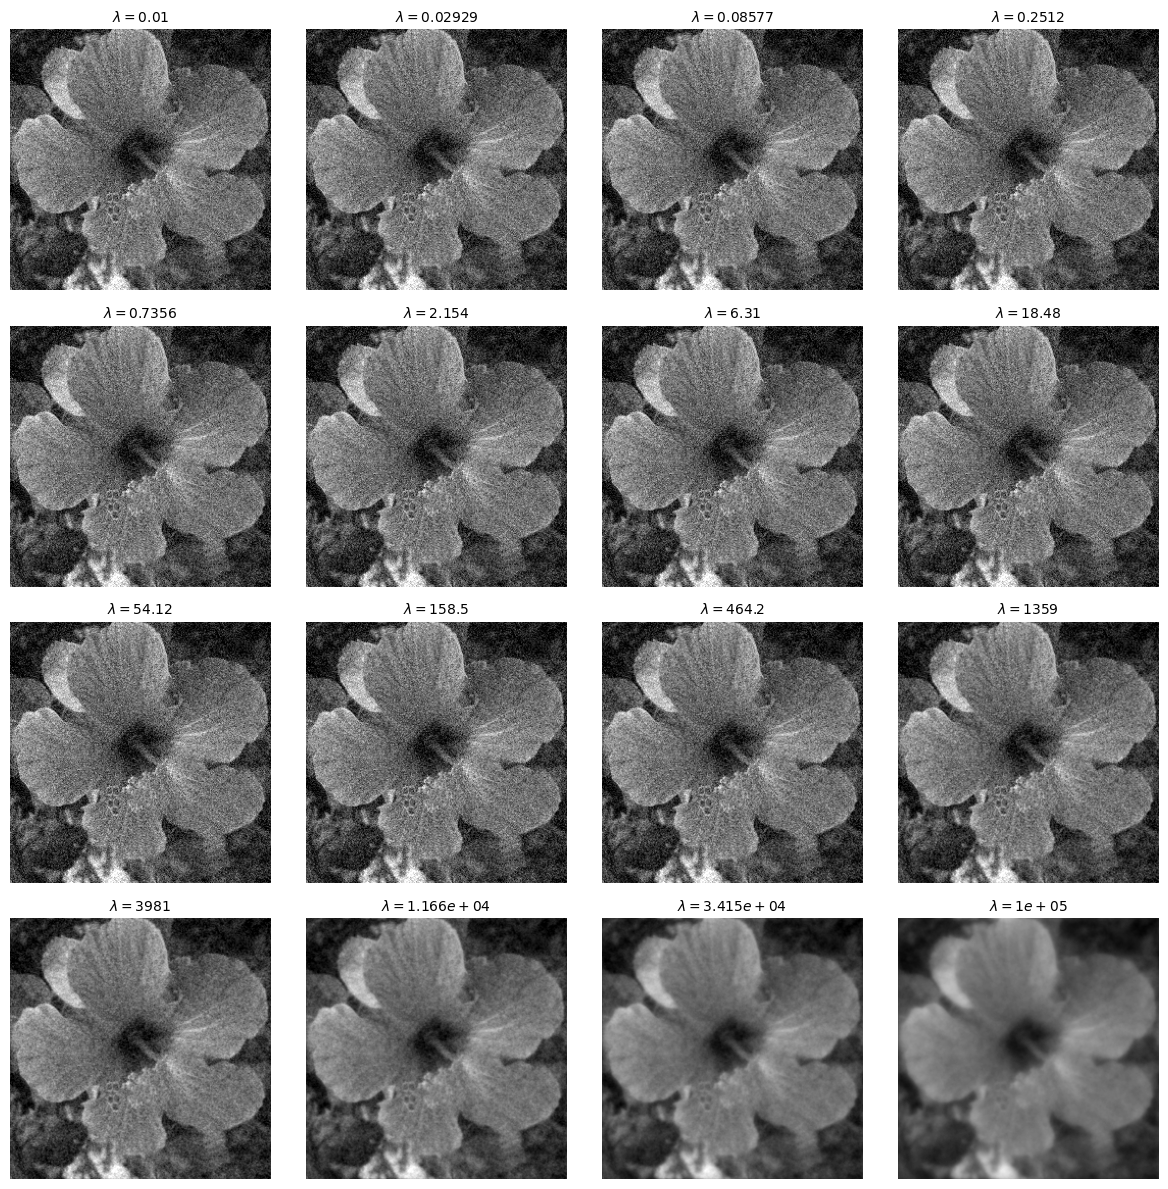

In [18]:
import matplotlib.pyplot as plt
import numpy as np

lambda_list = np.logspace(-2, 5, 16) 
nimgs = len(lambda_list)
ncols = 4
nrows = int(np.ceil(nimgs / ncols))

plt.figure(figsize=(12, 12))

for i, lambd in enumerate(lambda_list):
    ax = plt.subplot(nrows, ncols, i+1)
    fSob = fsob(yF, lambd, Sω_norm)     # image 2D numpy
    ax.imshow(clamp(fSob), cmap='gray', vmin=0, vmax=1)
    ax.set_title(r'$\lambda = %.4g$' % lambd, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

__`Pour la régularisation Sobolev nous n'avons pas besoin de descente de gradient, le critère Sobolev est quadratique en f, la solution du problème de minimisation s’écrit en Fourier, du type`__ :  
 - $ \hat f^{\star}(\omega) = \large \frac{\hat y(\omega)}{ 1+\lambda S(\omega) } \quad$ $\text{où}\quad S(\omega)=\|\omega\|^2. $
Construction de la pénalité Sobolev dans le domaine de Fourier avec un filtre dépendant de $S(ω)^2 =X^2 + Y^2$. On peut donc obtenir directement $f_λ$ par FFT/IFFT pour chaque λ, sans boucle d’itération.
 - En mode continu on a typiquement : $J_{Sob}(f)=∫S(ω)\hat f |(ω)∣^2dω,$ 
 - En mode discret cela se traduit par une somme sur les fréquences $J_{Sob}(f)=\sum S(ω)\hat f |(ω)∣^2dω,$

best_err : 94.567, best_lambda : 15117.751
best_E : inf, best_lambda : 15117.751 best lambda (erreur L2) = 1.51e+04


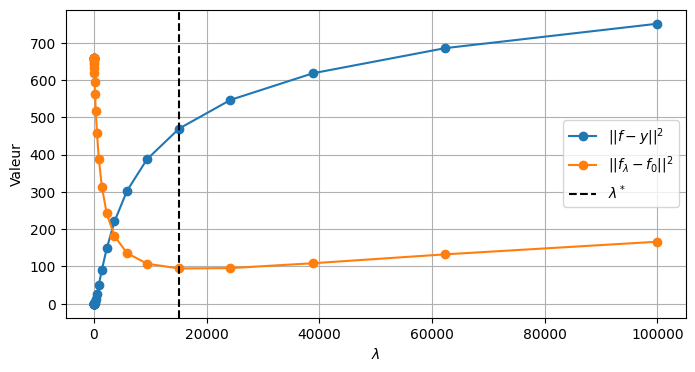

In [19]:
# en amont, une fois pour toutes
# Sω_norm : matrice S(ω) = |ω|^2 (ou équivalent discret)

best_E  = np.inf
best_f  = None
data_term_final=[]

best_lambda = 0
errors = []
best_err = np.inf

yF  = np.fft.fft2(y)
lambda_list = np.logspace(-3, 5, 40)

for i, lambd in enumerate(lambda_list):
    # solution fermée de la régularisation Sobolev
    Ff = yF / (1 + lambd * Sω_norm)
    f_sobolev = np.real(np.fft.ifft2(Ff))   # ici f_sobolev

    # critère E(f) pour CE lambda
    J_sob = np.sum(Sω_norm * np.abs(Ff)**2)
    E = 0.5 * np.linalg.norm(f_sobolev - y)**2 + lambd * J_sob
    # On met sum pour que l’erreur soit un nombre (un scalaire) et pas une image.
    errors.append(np.sum((f_sobolev - f0)**2))
    data_term_final.append(np.sum((f_sobolev - y)**2))

    if errors[-1] < best_err:
        best_err = errors[-1]
        best_lambda = lambd
        best_f = f_sobolev

print(f"best_err : {best_err:.3f}, best_lambda : {best_lambda:.3f}")
print(f"best_E : {best_E:.3e}, best_lambda : {best_lambda:.3f} best lambda (erreur L2) = {best_lambda:.3g}")

plt.figure(figsize=(8, 4))
plt.plot(lambda_list, data_term_final, '-o', label=r'$||f - y||^2$')
plt.plot(lambda_list, errors, '-o', label=r'$||f_\lambda - f_0||^2$')
plt.axvline(best_lambda, color='k', linestyle='--', label=r'$\lambda^*$')
plt.xlabel(r'$\lambda$')
plt.ylabel('Valeur')
plt.grid(True)
plt.legend()
plt.show()

#### _`Exercice :`_ 
- Calculer la solution pour plusieurs valeurs de $\lambda$ et 
- Choisir la valeur optimale de $\lambda$ ainsi que le débruitage optimal correspondant $|fSob|$. 
- Vous pouvez augmenter progressivement $\lambda$ et réduire considérablement le nombre d’itérations.

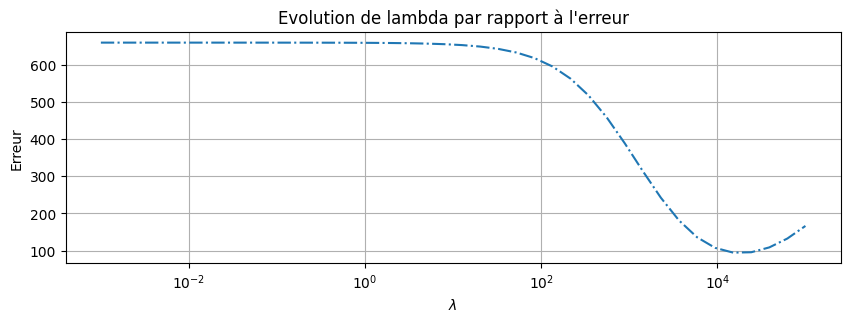

In [20]:
plt.figure(figsize=(10, 3))
plt.semilogx(lambda_list, errors, '-.')
plt.xlabel(r'$\lambda$')
plt.ylabel('Erreur')
plt.title('Evolution de lambda par rapport à l\'erreur')
plt.grid(True)
plt.show()

Pour la régularisation de Sobolev, l’erreur $\|f_\lambda - f_0\|^2$ décroît régulièrement avec $\lambda$ sur la plage testée, sans minimum marqué. Cela signifie que, dans ce cas, augmenter la régularisation améliore numériquement la proximité $L^2$ à l’image de référence, au prix d’un lissage visuel de plus en plus fort.

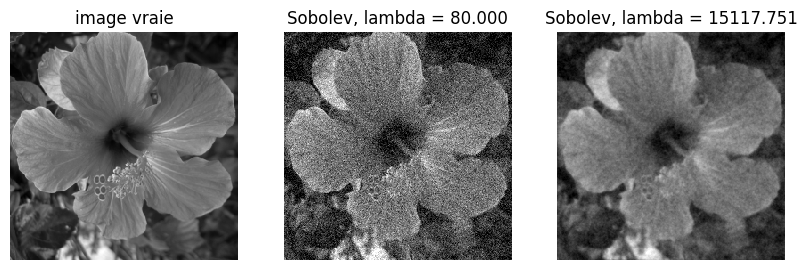

In [21]:
plt.figure(figsize=(10, 10))
imageplot(clamp(f0),'image vraie', [1,3,1])
imageplot(clamp(fsob(yF,80,Sω_norm)), f"Sobolev, lambda = {80:.3f}", [1,3,2])
imageplot(clamp(fsob(yF,best_lambda,Sω_norm)), f"Sobolev, lambda = {best_lambda:.3f}", [1,3,3])
plt.show()

`La figure ci‑dessus illustre l’effet de la régularisation de Sobolev sur l’image bruitée`. 

- Pour $\lambda = 80$, le filtre en Fourier reste peu sélectif et le bruit de haute fréquence demeure très présent, si bien que la reconstruction est visuellement proche de l’image bruitée. 

- Lorsque $\lambda$ augmente fortement (par exemple $\lambda \approx 1.4\times 10^4)$, le filtrage atténue davantage les hautes fréquences et l’image devient plus lisse, mais les détails fins de la fleur sont également estompés et le contraste se réduit. 

- Cette évolution met en évidence que, dans ce modèle quadratique, l’augmentation de $\lambda$ agit surtout comme un lissage global de l’image, avec un compromis délicat entre réduction du bruit et préservation des structures.

### _`Formule SNR`_
Avec une image propre $f_0$ et une reconstruction $f_{Sob}$, le SNR (en dB) se définit par : $SNR=20*log_{10} \Large \frac {||f_0||^2}{||f_0−f_{denoise}||^2}$

Le rapport signal/bruit (SNR) est meilleur quand il est fort, et pas l'inverse.
- `SNR élevé` indique le signal est beaucoup plus fort que le bruit → image / son / classement clair et propre.
- `SNR faible` indique que le bruit est du même ordre ou plus fort que le signal → résultat très bruité, difficile à interpréter.


In [22]:
def snr(f0, f_denoise):
    num = np.linalg.norm(f0)             # ||f0||
    den = np.linalg.norm(f0 - f_denoise) # ||f0 - fsob||
    return 20 * np.log10(num/den)

Le poids fréquentiel $S(ω)=||\omega||^2$ agit comme un filtre passe‑bas pénalisant les hautes fréquences.

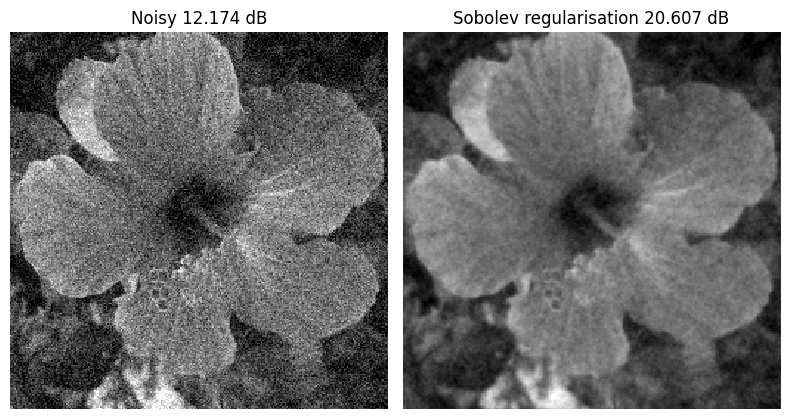

In [23]:
lambd = best_lambda
fSob   = fsob(yF,lambd,Sω_norm)
enoisy = snr(f0, y)  # image bruitée 
esob   = snr(f0, fSob) # image regularisée Sobolev

plt.figure(figsize=(8,8))

imageplot(clamp(y),    f"Noisy {enoisy:.3f} dB",    [1, 2, 1])
imageplot(clamp(fSob), f"Sobolev regularisation {esob:.3f} dB", [1, 2, 2])

plt.tight_layout()
plt.show()

_`Description sur le plan visuel`_
Image bruitée à gauche (12 dB): 
- grain très fort partout, contours noyés.
Regularisation Sobolev à droite (20 dB):  
- bruit réduit, bords et structures mieux visibles, 
- mais texture de la fleur lissée et
- bruit résiduel fin.

Ce résultat est le compromis attendu de la régularisation Sobolev filtre de type $\Large \frac{1}{1+λ||ω||^2}$.
Elle atténue les hautes fréquences (bruit),mais lisse aussi les détails fins du signal. Lorque l'on compare des méthodes de débruitage, celle qui a le SNR (en dB) le plus élevé est en général la plus performante.

## `I. Á priori et Régularisation`
Une image discrète pixélisée $f \in \mathbb{R}^N$ où $N=n \times n$ le nombre de pixel $\nabla f(x) \in \mathbb{R}^2$ calculé à l’aide de différences finies.
- le gradient au point $x$ et définit tel que : $\nabla f(x) = \large \left(  \frac{\partial f(x)}{\partial x_1},\frac{\partial f(x)}{\partial x_2} \right)$
- la norme euclidienne $L_2$ du gradient $d(x) = \|\nabla f(x)\| $ en chaque pixel $d(i,j)= \sqrt{(∂_x f(i,j))^2 +(∂_yf(i,j))^2}$
- $Gr = grad(f_{TV})$ est le champ de gradients de l’image, de taille $(n,n,2)$
- mathématiquement, pour la TV lissée $J_{\epsilon}(f) = \int \|\nabla f(x)\|^2 dx = \int \sqrt{\epsilon^2 + \|\nabla f(x)\|^2} dx$
- le gradient (au sens $L_2$) est $GradJ_{\epsilon}(f) = - div \left( \frac{\nabla f}{\sqrt{\epsilon^2 + |\nabla f|^2}} \right)$
__Pour une image__ $f$ donnée $J(f) \in \mathbb{R}$ __est l’information `à priori` imposée sur la forme de l’image recherchée, indépendamment des données bruitées__ $y$. 
 - l’énergie variationnelle pour la restauration d’image  $E(f) = \frac{1}{2}\|y-f\|^2 + \lambda J(f) $
Le débruitage d’une image $y$ est obtenu par une minimisation variationnelle $ \min_f \frac{1}{2}\|y-f\|^2 + \lambda J(f) $ 
 - il combine un ajustement aux données (généralement via une norme $L^2$ ) et l’à priori.
 - Si $J(f)$ est une fonction convexe de $f$, alors le minimum existe et il est unique. 

Si $J(f)$ est un fonction continue de l'image $f$, un minimiseur de ce problème peut être calculé par descente de gradient. 
 - Cela définit une suite d’images $f^{(\ell)}$ indexée par $\ell \in \mathbb{N}$ tel que : $ f^{(\ell+1)} = f^{(\ell)} + \tau \left( f^{(\ell)}-y + \lambda \text{Grad}J(f^{(\ell)}) \right). $
 - Notons que $f^{(\ell)}$ converge vers une solution du problème lorsque $\ell \rightarrow +\infty$
 - $\large \tau$ requiert d'être suffisamment faible, plus précisément, si la fonction $J$ est deux fois différenciable : $ \tau < \frac{2}{1 + \lambda \max_f \|D^2 J(f)\|}$
 - Le paramètre  $\tau>0$ doit être adapté au niveau de bruit, accroitre sa valeur moyenne rend le débruitage plus agressif. 

best_E : 352.279, best_lambda : 0.010 best lambda (erreur L2) = 0.6309573444801934


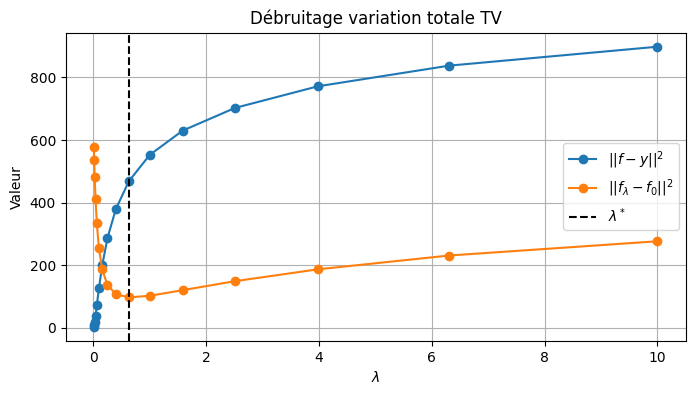

In [24]:
import matplotlib.pyplot as plt
import numpy as np

niter   = 100
epsilon = 0.5
ncols   = 4
best_E  = np.inf
best_f  = None
data_term_final=[]
errors = []

lambda_list = np.logspace(-2, 1, 16)

for i, lambd in enumerate(lambda_list):
    fTV = y.copy()
    E   = []
    tau = 2 / (1 + lambd * 8 / epsilon)
    for it in range(niter):
        
        Gr  = grad(fTV)                             # champ de gradients de l’image, de taille (n,n,2).
        l2  = np.sqrt(np.sum(Gr**2, axis=2))        # norme euclidienne pixel par pixel
        den = np.sqrt(epsilon**2 + l2**2)           # (n,n)
        den_expanded = np.expand_dims(den, axis=2)  # (n,n,1)
        P = Gr / den_expanded                       # (n,n,2)
        G = -div(P)                                 # le gradient au sens L2
        fTV = fTV - tau * (fTV - y + lambd * G)
        J_tv = np.sum(np.sqrt(epsilon**2 + l2**2))   
        E.append(0.5*np.linalg.norm(fTV - y)**2 + lambd * J_tv) # ton code de débruitage
    
    errors.append( np.sum( (fTV - f0)**2) )
    data_term = np.sum((fTV - y)**2)
    data_term_final.append(data_term)
    if E[-1] < best_E:
        best_E = E[-1]
        best_lambda = lambd
        best_f = fTV

errors = np.array(errors)
idx_best = np.argmin(errors)
best_lambda_err = lambda_list[idx_best]

print(f"best_E : {best_E:.3f}, best_lambda : {best_lambda:.3f} best lambda (erreur L2) = {best_lambda_err}")

plt.figure(figsize=(8, 4))
plt.plot(lambda_list, data_term_final, '-o', label=r'$||f - y||^2$')
plt.plot(lambda_list, errors, '-o', label=r'$||f_\lambda - f_0||^2$')
plt.axvline(best_lambda_err, color='k', linestyle='--', label=r'$\lambda^*$')
plt.xlabel(r'$\lambda$')
plt.ylabel('Valeur')
plt.title('Débruitage variation totale TV')
plt.grid(True)
plt.legend()
plt.show()

- La figure ci‑dessus illustre l’influence du paramètre de régularisation $\lambda$ dans le modèle de débruitage par variation totale. 

- Lorsque $\lambda$ augmente, le terme d'attache aux données $||f - y||^2$ croît de manière monotone, ce qui traduit un lissage de plus en plus marqué et un éloignement progressif de l’image observée bruitée.  

- En revanche, l’erreur de reconstruction $||f_\lambda - f_0||^2$ présente une forme en $U$ avec un minimum pour $\lambda^* \approx 0{,}7$, ce qui met en évidence un compromis optimal entre fidélité aux données et régularisation. 

- Pour $\lambda < \lambda^*$, la régularisation est insuffisante et l’image reste trop bruitée, tandis que pour $\lambda > \lambda^*$, la régularisation devient excessive et efface des détails importants, ce qui dégrade à nouveau la qualité de la reconstruction.

## _`"A priori" de variation totale TV`_
`La variation totale est une norme qui contrairement à la norme de Sobolev, est capable de prendre en compte les discontinuités de type marches (bords nets)`.
- La variation totale d’une image lisse $f$ est définie par $J(f) = \int \|\nabla f(x)\| \,\mathrm{d}x$.
- Elle s’étend aux images non lisses présentant des discontinuités en marche. 
- La variation totale d’une image est égale à la longueur totale de ses ensembles de niveau : 

   - $J(f) = TV(f) = \int_{-\infty}^{+\infty} L(S_t(f)) \,\mathrm{d}t$
      - où $S_t(f)$ désigne l’ensemble de niveau $\{x∈Ω:f(x)=t\}$ de l’image $f$, $S_t(f) = \{ x \mid f(x) = t \}$
      - et $L(S_t(f))$ sa longueur (périmètre)

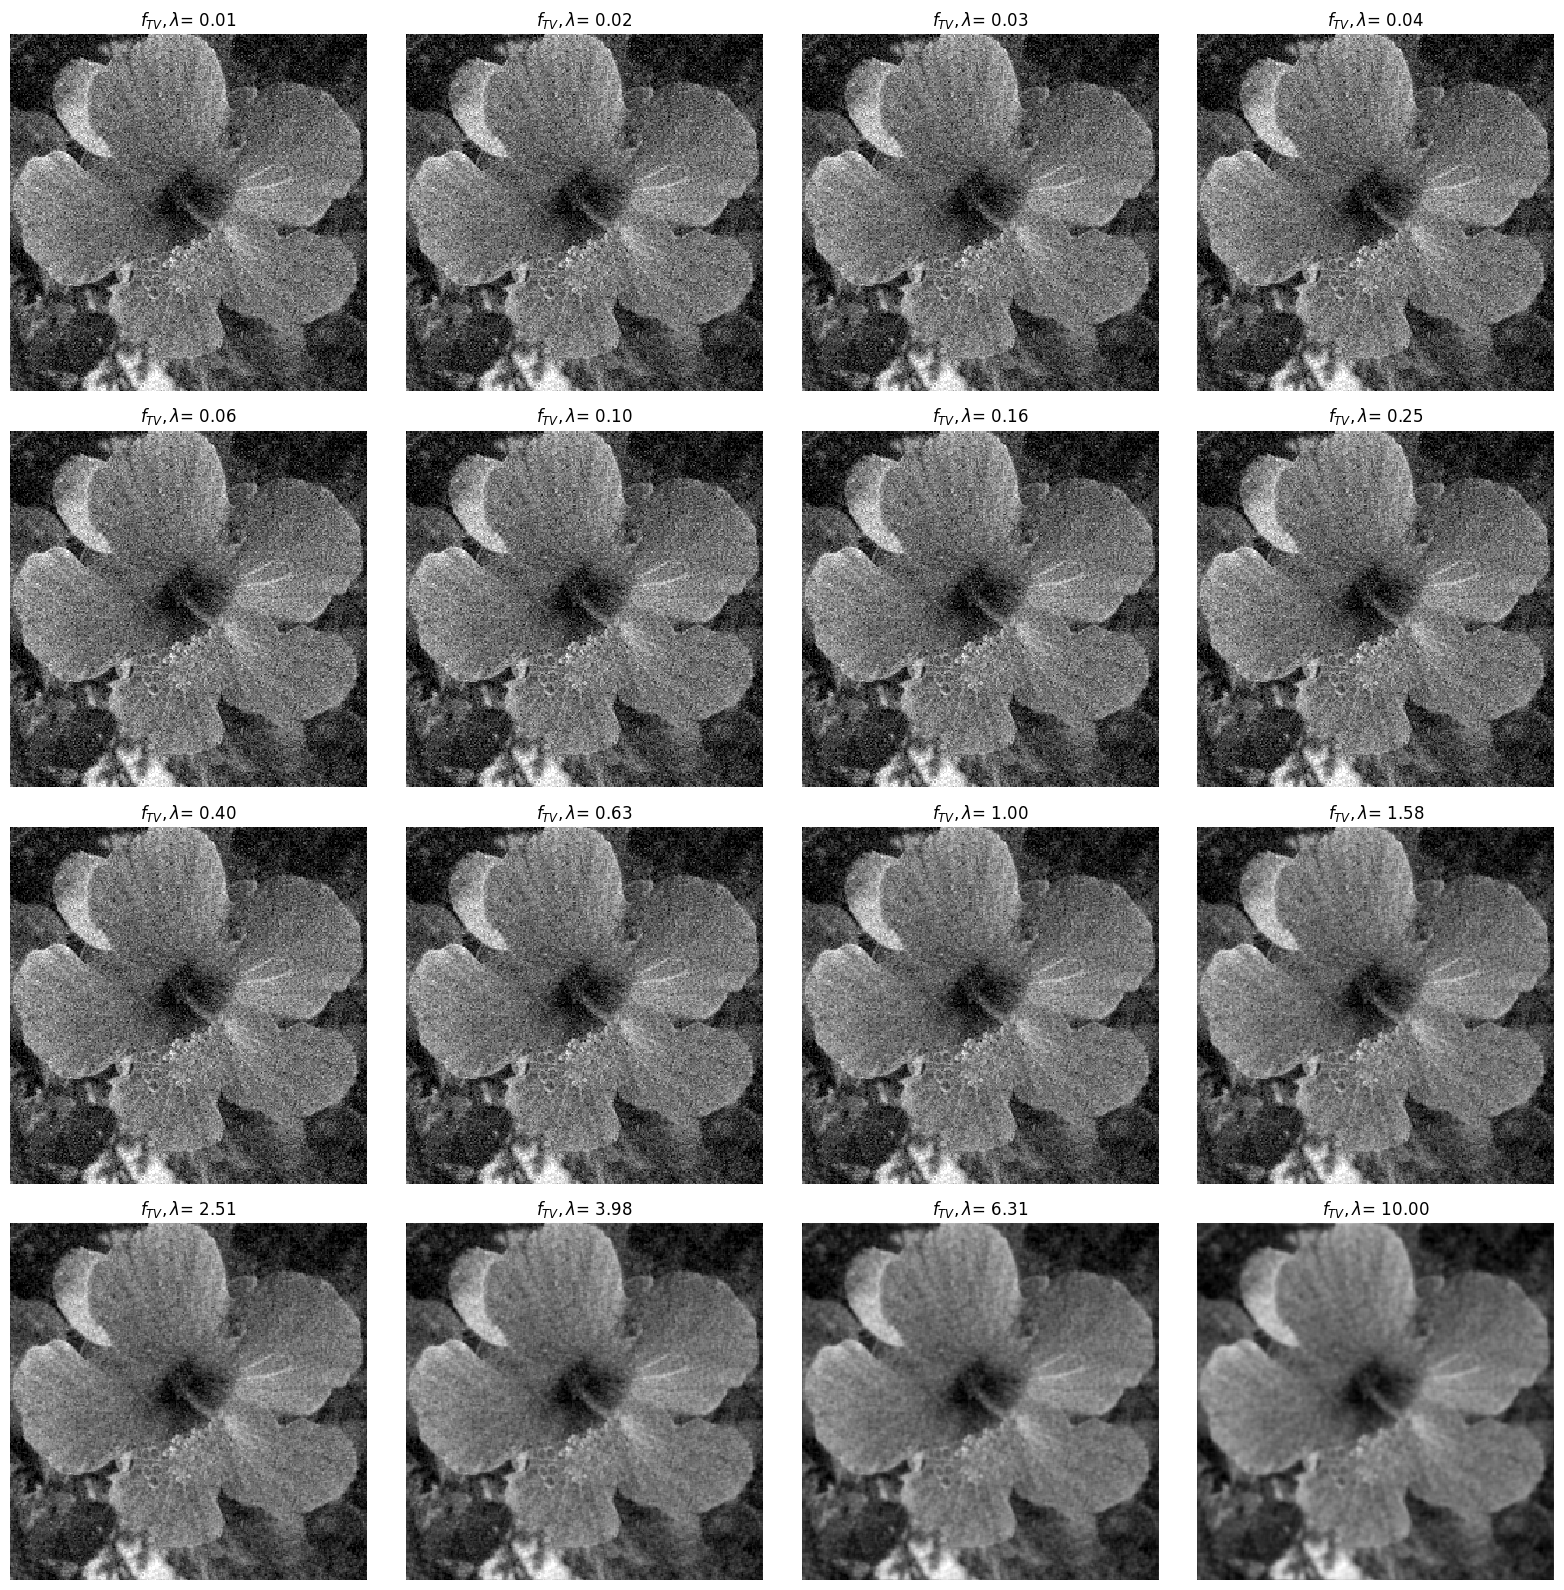

In [59]:
import matplotlib.pyplot as plt
import numpy as np

niter   = 100
ncols = 4

lambda_list = np.logspace(-2, 1, 16)
nimgs = len(lambda_list)
nrows = int(np.ceil(nimgs / ncols))

plt.figure(figsize=(16,16))

for it in range(niter):
    fTV = y.copy()
    for i, lambd in enumerate(lambda_list):
        plt.subplot(nrows, ncols, i+1)
        Gr  = grad(fTV)
        l2  = np.sqrt(np.sum(Gr**2, axis=2))
        den = np.sqrt(epsilon**2 + l2**2)
        den_expanded = np.expand_dims(den, axis=2)
        P = Gr / den_expanded
        G = -div(P)
        fTV = fTV - tau * (fTV - y + lambd * G)
        imageplot(clamp(fTV), r"$f_{TV}, \lambda$" f"= {lambd:.2f}", [])
        plt.axis('off') 

plt.tight_layout()
plt.show()

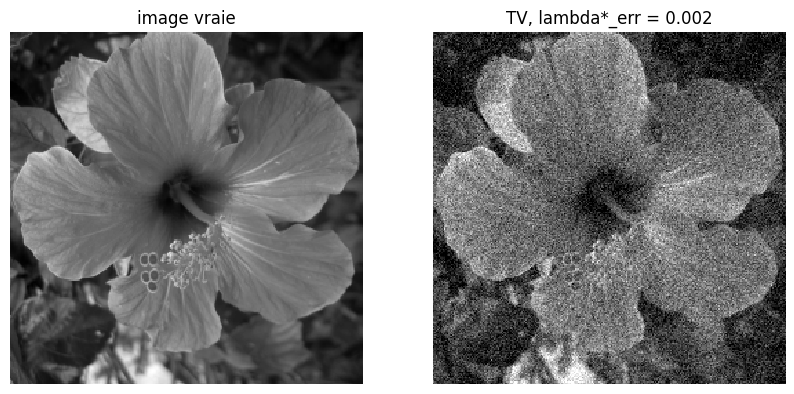

In [43]:
# après la boucle
errors = np.array(errors)
idx_best = np.argmin(errors)
best_lambda_err = lambda_list[idx_best]

# recalculer fTV pour ce lambda (ou le stocker pendant la boucle)
fTV = y.copy()

lambd = best_lambda_err
tau = 2 / (1 + lambd * 8 / epsilon)
niter = 50 

for it in range(niter):
    Gr  = grad(fTV)
    l2  = np.sqrt(np.sum(Gr**2, axis=2))
    den = np.sqrt(epsilon**2 + l2**2)
    den_expanded = np.expand_dims(den, axis=2)
    P = Gr / den_expanded
    G = -div(P)
    fTV = fTV - tau * (fTV - y + lambd * G)

best_f_err = fTV
plt.figure(figsize=(10, 10))
imageplot(clamp(f0),'image vraie', [1,2,1])
imageplot(clamp(best_f_err), f"TV, lambda*_err = {best_lambda_err:.3f}", [1,2,2])

La comparaison entre l’image vraie et la reconstruction TV pour $\lambda^*_{\text{err}} \approx 0{,}71$ montre que la forme globale de la fleur et les principaux contours sont bien préservés. En revanche, les détails fins sont atténués et un bruit résiduel subsiste, ce qui reflète le compromis entre réduction du bruit et conservation des structures.

##### _`Exercise 2 : Calculer la variation totale de`_ $|f_0|$
Pour une image discrète, on approxime cette intégrale par une somme sur les pixels.
`Formule discrète` 
 - si l'image est $f∈R^{n×n}$
 - que $grad(f)$ renvoie un tableau Gr de taille (n, n, 2) dérivées finies en x et y, 
 - alors la TV isotrope se calcule par : $J(f)≈\sum_{i,j}||∇f_{i,j}||=\sum_{i,j}\sqrt{(∂_xf_{i,j})^2+(∂_yf_{i,j})^2}$


In [60]:
eps = 0.5   # par exemple
l_2 = np.sqrt(Gr[:, :, 0]**2 + Gr[:, :, 1]**2)        # ||∇f|
J_tv_eps = np.sum(np.sqrt(eps**2 + l_2**2))
print(f"J_tv_eps : {J_tv_eps}")

J_tv_eps : 32943.95335505142


Pour une image $f$ donnée $J(f) \in \mathbb{R}$ associe un score qui est supposé être faible pour l’image d’intérêt. 
Le débruitage de y est obtenu par minimisation variationnelle combinant un ajustement aux données $ \min_f \frac{1}{2}\|f - y\|^2 + \lambda J(f) $ 
Si $J(f)$ est une fonction convexe de $f$, alors le minimum existe et il est unique. 

#### _`Le Gradient de la norme TV :`_ 
$ \text{Grad}J(f) = \text{div}\left(\large \frac{\nabla f}{\|\nabla f\|} \right) $ non défini au pixel $x$ si $\nabla f(x)=0$ difficile à minimiser, le flot de gradient est mal défini.
Considérons une nomalisation douce de TV : $J_\epsilon(f) = \int \sqrt{ \varepsilon^2 + \| \nabla f(x) \|^2 } dx $ 
  - Ici $||u||$ la norme euclidienne du vecteur $u$. 
  - On substitue $\|u\|$ par $ \sqrt{\varepsilon^2 + \|u\|^2} $ qui est la fonction lissée


We display (in 1D) the smoothing of the absolute value.

0.5001003911248301


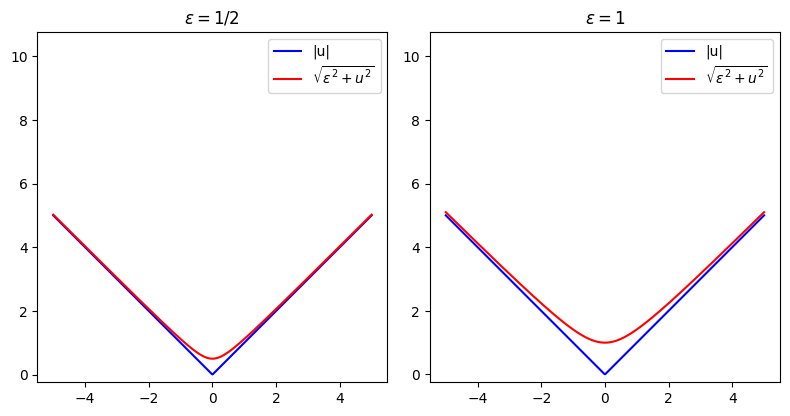

In [61]:
import numpy as np
import matplotlib.pyplot as plt

u = np.linspace(-5, 5, 500)  # vecteur 1D

plt.figure(figsize=(8, 8))

val = np.sqrt(eps**2 + u**2)
min = np.argmin(val)
print(val[min])

eps = 0.5
plt.subplot(1, 2, 1)
plt.plot(u, np.abs(u), 'b', label='|u|')
plt.plot(u, np.sqrt(eps**2 + u**2), 'r', label=r'$\sqrt{\varepsilon^2 + u^2}$')
plt.title(r'$\varepsilon = 1/2$')
plt.axis('square')
plt.legend()

eps = 1.0
plt.subplot(1, 2, 2)
plt.plot(u, np.abs(u), 'b', label='|u|')
plt.plot(u, np.sqrt(eps**2 + u**2), 'r', label=r'$\sqrt{\varepsilon^2 + u^2}$')
plt.title(r'$\varepsilon = 1$')
plt.axis('square')
plt.legend()

plt.tight_layout()
plt.show()

Le gradiant de la norme TV lissé est $ \text{Grad}J(f) = \text{div}\left( \frac{\nabla f}{\sqrt{\varepsilon^2 + \|\nabla f\|^2}} \right)$


 - Lorsque $\varepsilon$ augmente, le gradiant de la norme TV lissé approche le Laplacian (normalisé par $1/\varepsilon$).

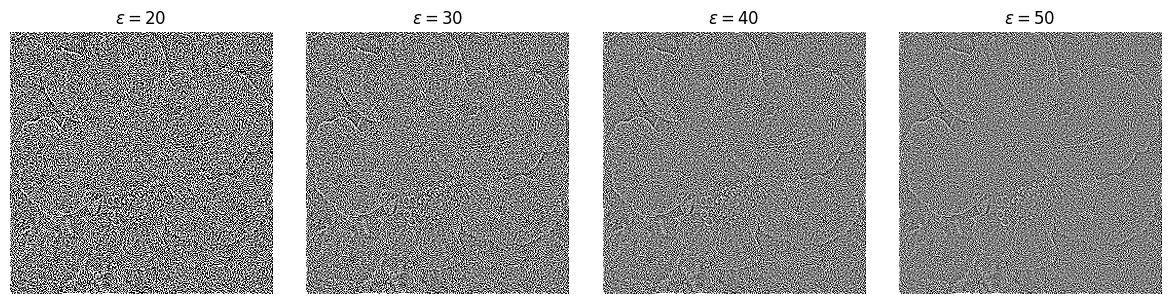

In [62]:
epsilon_list = [20,30,40,50]
fTV = y.copy()

G_list = []
for eps in epsilon_list:
    Gr  = grad(fTV)
    l_2 = np.sqrt(np.sum(Gr**2, axis=2))
    denom = np.sqrt(eps**2 + l_2**2)
    P = Gr / np.expand_dims(denom, axis=2)
    G = -div(P)
    G_list.append(G)

v = np.std(G_list)                       # échelle fixée
plt.figure(figsize=(12, 3))
for i, (eps, G) in enumerate(zip(epsilon_list, G_list), 1):
    plt.subplot(1, 4, i)
    plt.imshow(G, cmap='gray', vmin=float(0.7*-v), vmax=float(0.7*v))
    plt.title(rf"$\epsilon = {eps}$")
    plt.axis('off')

plt.tight_layout()
plt.show()

- Pour $\epsilon$ très petit, on est presque sur le TV pur les contours sont très marqués, le champ varie beaucoup et réagit fort au bruit.
- Lorsque $\epsilon$ augmente, la normalisation devient plus douce, les réponses aux gradients faibles sont plus régularisées le gradient TV devient plus lisse, on voit surtout les grandes structures, le bruit fin disparaît.

## __`Débruitage par régularisation totale`__ 

 - Nous définissons le paramètre de régularisation $\lambda$.
 - Le pas de temps pour la diffusion doit vérifier: $\Large \tau < \frac{2}{1 + \lambda 8 / \varepsilon}$

Le paramètre  $\tau>0$ doit être adapté au niveau de bruit, accroitre sa valeur moyenne rend le débruitage plus agressif. 

In [238]:
epsilon = 4e-2 # 
lambd = 6.210e-01
tau = 2 / (1 + lambd * 8 / epsilon)
print(f"tau : {tau}")

tau : 0.01597444089456869


`Inintialisation de la minimisation`

- $f_0$ image réelle 
- $y$ image $f_0$ bruitée

`Calcul du Gradiant pour la norme TV lissée`.
Le signe « moins » vient du fait qu’en analyse variationnelle, le gradient au sens de $L_2$ d’une énergie J vaut −div(…), et la descente de gradient utilise l’opposé de ce gradient.

`Un pas de descente de Gradiant`.

Si $J(f)$ est un fonction continue de l'image $f$, un minimiseur de ce problème peut être calculé par descente de gradient. 
 - Cela définit une suite d’images $f^{(\ell)}$ indexed by $\ell \in \mathbb{N}$ tel que : $ f^{(\ell+1)} = f^{(\ell)} + \tau \left( f^{(\ell)}-y + \lambda \text{Grad}J(f^{(\ell)}) \right). $
 - Notons que $f^{(\ell)}$ converge lorsque $\ell \rightarrow +\infty$ 
 - $\large \tau$ requiert d'être faible, si la fonction $J$ est deux fois différenciable $ \tau < \large \frac{2}{1 + \lambda \max_f \|D^2 J(f)\|}. $
 - Le paramètre  $\tau>0$ doit être adapté au niveau de bruit, accroitre sa valeur moyenne rend le débruitage plus agressif. 

`«Apriori de Sobolev»`
 - L’apriori d’image de Sobolev est un a priori quadratique, c’est‑à‑dire une (pseudo-)norme de Hilbert.
 - « Nous chargeons d’abord une image propre (sans bruit). »

##### `Exercise 3 :` 
 - Calcul de la descente de gradient monitorer la minimisation de l'énergie.

`Gradient de l’énergie totale`
 - On minimise $ E(f) =  \frac{1}{2}\|f - y\|^2 + \lambda J(f) $
 - Le gradient $L_2$ de E est $\nabla E(f) = f − y  + λ.GradJ(f)$
 - Un pas de descente de gradient s’écrit alors  $ f^{(\ell+1)} = f^{(\ell)} - \tau \nabla E(f^{(l)}) = f^{(\ell)} - \tau \left( f^{(\ell)}-y + \lambda \text{Grad}J(f^{(\ell)}) \right)$  

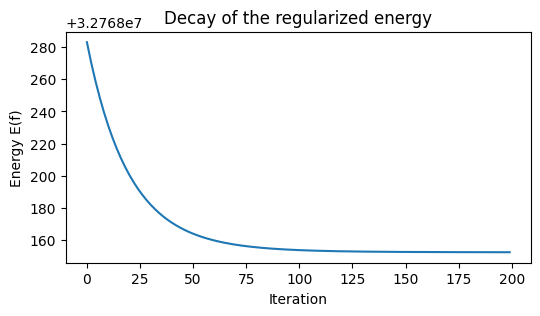

In [63]:
niter = 200
E = []

fTV = y.copy()
fTV_last = fTV
for it in range(niter):
    # gradient de la partie TV lissée
    Gr = grad(fTV)                                    # (n,n,2)
    l2 = np.sqrt(np.sum(Gr**2, axis=2))  
    G  = -div(Gr / np.sqrt(eps**2 + np.expand_dims(l2**2, axis=2)))
    # descente de gradient
    fTV = fTV - tau * (fTV - y + lambd * G)
    fTV_last = fTV
    # énergie actuelle
    J_tv_eps = np.sum(np.sqrt(eps**2 + l2**2))
    E.append(0.5*np.linalg.norm(fTV - y)**2 + lambd*J_tv_eps)

plt.figure(figsize=(6,3))
plt.plot(E)
plt.xlabel('Iteration')
plt.ylabel('Energy E(f)')
plt.title('Decay of the regularized energy')
plt.show()

La décroissance est rapide, l’énergie se stabilise, la descente semble converger pour le couple $(λ,ϵ,τ)$.

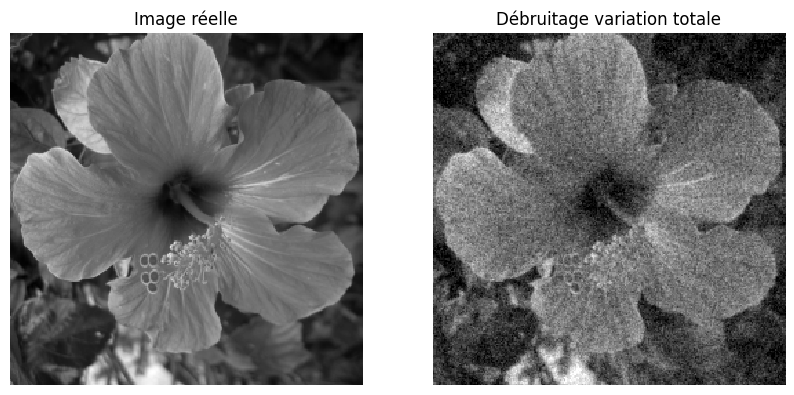

In [64]:
plt.figure(figsize=(10, 10))
imageplot(clamp(f0), "Image réelle", [1,2,1])
imageplot(clamp(fTV_last), "Débruitage variation totale", [1,2,2])

best lambda (SNR) = 6.210e-01, SNR = 20.500 dB


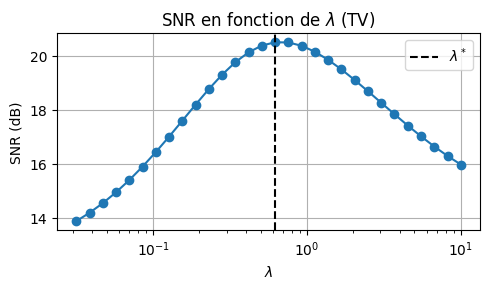

In [65]:
import numpy as np
import matplotlib.pyplot as plt

def tv_denoise(y, lambd, niter=100, epsilon=0.5):
    f = y.copy()
    tau = 2 / (1 + lambd * 8 / epsilon)
    for _ in range(niter):
        Gr  = grad(f)
        l2  = np.sqrt(np.sum(Gr**2, axis=2))
        JTV   = -div(Gr / np.sqrt(epsilon**2 + np.expand_dims(l2**2, axis=2)))
        f   = f - tau * (f - y + lambd * JTV)
    return f

lambda_list = np.logspace(-1.5, 1, 30)   # de 1e-5 à 1
snrs = []

for lambd in lambda_list:
    f_tv = tv_denoise(y, lambd, niter=100, epsilon=0.5)
    snrs.append(snr(f0, f_tv))

snrs = np.array(snrs)
best_idx = np.argmax(snrs)
best_lambda_snr = lambda_list[best_idx]
best_snr = snrs[best_idx]

print(f"best lambda (SNR) = {best_lambda_snr:.3e}, SNR = {best_snr:.3f} dB")

plt.figure(figsize=(5,3))
plt.semilogx(lambda_list, snrs, '-o')
plt.axvline(best_lambda_snr, color='k', ls='--', label=r'$\lambda^*$')
plt.xlabel(r'$\lambda$')
plt.ylabel('SNR (dB)')
plt.title('SNR en fonction de $\lambda$ (TV)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

La forme « bosse » centrée autour de λ≈0.6 est ce qu’on attend, un compromis optimal entre conservation des détails (petit λ) et lissage du bruit (grand λ).

Indique dans le rapport que la sélection de $λ$ par maximisation du SNR (en supposant $f_0$ connu) donne ici $0.6≈λ^∗$ et un gain de SNR d’environ 8 dB par rapport à l’image bruitée, ce qui justifie ce choix pour la suite (comparaison avec ROF, ondelettes, etc.).

Nous choisissons le paramètre de régularisation $\lambda$ en maximisant le SNR entre l’image reconstruite et l’image de référence. Pour cette image, la valeur optimale est $\lambda^* \approx 0{,}6$, ce qui permet de faire passer le SNR de l’image bruitée d’environ 12 dB à plus de 20 dB, tout en préservant correctement les contours de l’objet.

- `SNR élevé` indique le signal est beaucoup plus fort que le bruit → image / son / classement clair et propre.
- `SNR faible` indique que le bruit est du même ordre ou plus fort que le signal → résultat très bruité, difficile à interpréter.

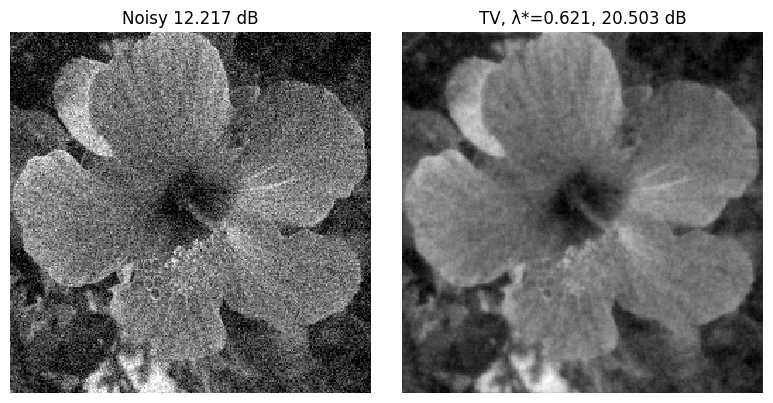

In [66]:
f_tv_star = tv_denoise(y, best_lambda_snr, niter=200, epsilon=epsilon)
snr_star = snr(f0, f_tv_star)

plt.figure(figsize=(8,4))
imageplot(clamp(y),         f"Noisy {enoisy:.3f} dB",        [1, 2, 1])
imageplot(clamp(f_tv_star), f"TV, λ*={best_lambda_snr:.3f}, {snr_star:.3f} dB", [1, 2, 2])
plt.tight_layout()
plt.show()

## _`Mise en regard des méthodes de débruitage`_
- `le débruitage par variation totale (TV)` 
- `un seuillage dur dans un cadre serré d’ondelettes invariant par translation`.

`Le seuillage dur en ondelettes est décrit comme :`
$\large w_{j,k}^{(\text{seuil})} = \left\{ \begin{array}{ll}  w_{j,k}  \text{ si } |w_{j,k}| \ge T\\  0        \text{.....si } |w_{j,k}| < T  \end{array} \right.$
- on conserve les gros coefficients (en valeur absolue) et on met à zéro les petits.
- les petits coefficients sont supposés majoritairement dus au bruit (gaussien de faible amplitude).
Le cadre serré d’ondelettes invariant par translation dit du système ${\psi_{j,k}}$ qu'il vérifie $\large||f||^2 =\sum_{j,k}|\langle f,\psi_{j,k}\rangle|^2$
Pour une image 2D $y[i,j]$ et une ondelette 2D $\psi_{j,k}[i,j]$ $=>$ $w_{j,k}=\langle y,\psi_{j,k}\rangle=\sum_i\sum_jy[i,j]\psi_{j,k}[i,j]$ 
_`Dans ce cadre :`_
1. calculer les coefficients $\large w_{j,k}=⟨y,\psi_{j,k}⟩\text{, } \large ⟨⋅,⋅⟩$ le produit scalaire.
    - l’« amplitude » de l'image $\large y$ dans la direction de cette ondelette.
    - $\large w_{j,k}=⟨y,\psi_{j,k}⟩$ le coefficient d’ondelette obtenu en projetant y sur $\psi_{j,k}$,
    - $\large \psi_{j,k}$ l’ondelette de niveau j et position k.  
2. appliquer le seuillage dur coefficient par coefficient comme ci‑dessus.
3. reconstruir l’image débruitée $f$ par la synthèse du frame

Multiplier le signal par l’ondelette point par point et additionner le tout. Plus l’ondelette ressemble localement au signal, plus le coefficient $w_{j,k}$ est grand.

`1. Idée clé : en 2D`, $\psi_{j,k}$ $=>$ `petit motif 2D`
- En 2D, une ondelette $\psi_{j,k}$ est juste un petit motif 2D (un patch) à une: 
    - certaine taille (échelle j) et 
    - position (indices de translation $k=(k_1,k_2))$
Pour des ondelettes séparables on construit 3 familles 2D par produit tensoriel d'ondelettes / fonctions d’échelle 1D
- horizontale $\psi_(x,y)^{(h)}=\phi(x)\psi_(y)$ 
- verticale $\psi_(x,y)^{(v)}=\psi_(x)\phi(y)$
- diagonale $\psi_(x,y)^{(d)}=\psi_(x)\psi_(y)$
Puis on les dilate/translater pour fabriquer $\large \psi_{j,k_1,k_2}^{(h)},\psi_{j,k_1,k_2}^{(v)},\psi_{j,k_1,k_2}^{(d)}$
On peut les voir comme des filtres 2D qui réagissent à :
- bords horizontaux (détails verticaux),
- bords verticaux (détails horizontaux),
- coins/diagonales (détails diagonaux).
`2. Version « filtrage / convolution »`
Pour un niveau $j$ on a en 2D nous avons 3 filtres correspondant pour l’ondelette :
- horizontale $h_j^{(h)}$,
- verticale $h_j^{(v)}$,
- diagonale $h_j^{(d)}$.
Les coefficients d’ondelettes au niveau $j$ s’interprètent comme : $\omega_j^{(h)} = y * h_j^{(h)}\text{ , } \omega_j^{(v)} = y * h_j^{(v)}\text{ , } \omega_j^{(d)} = y * h_j^{(d)}$
- où ∗ est une convolution 2D (ou corrélation suivant la convention).
- chaque « position » $k=(k_1,k_2)$ correspond simplement à un pixel dans ces cartes de coefficients : 
    - $\omega_j^{(h)}[k_1,k_2]$ = produit scalaire de y avec la ondelette $\large \psi_{j,k_1,k_2}^{(h)}$
Nous ne manipulons pas $\psi_{j,k}$ comme une fonction, elle est implémentée par le filtre appliqué à l’image.


In [67]:
import numpy as np
from scipy.signal import convolve2d  

# ondelette "horizontale" très simple (type Haar 2D)
psi_h = np.array([[1,  1],[-1, -1]], dtype=float)
psi_h = psi_h / np.linalg.norm(psi_h)   # norme = 2 -> coeffs = 1/2 
# ondelette "verticale"
psi_v = np.array([[1, -1],[1, -1]], dtype=float)
psi_v = psi_v / np.linalg.norm(psi_v)   # norme = 2 -> coeffs = 1/2
# ondelette "diagonale"
psi_d = np.array([[1, -1],[-1, 1]], dtype=float)
psi_d = psi_d / np.linalg.norm(psi_d)   # norme = 2 -> coeffs = 1/2

### `1. Première convolution : analyse (passer en ondelettes)`
 - __But__ : extraire les coefficients d’ondelettes (les détails).
`Version « filtrage / convolution »`
Pour un niveau $j$ on a en 2D nous avons 3 filtres correspondant pour l’ondelette :
- horizontale $h_j^{(h)}$,
- verticale $h_j^{(v)}$,
- diagonale $h_j^{(d)}$.
Les coefficients d’ondelettes au niveau $j$ s’interprètent comme : $\omega_j^{(h)} = y * h_j^{(h)}\text{ , } \omega_j^{(v)} = y * h_j^{(v)}\text{ , } \omega_j^{(d)} = y * h_j^{(d)}$
- où ∗ est une convolution 2D (ou corrélation suivant la convention).
- chaque « position » $k=(k_1,k_2)$ correspond simplement à un pixel dans ces cartes de coefficients : 
    - $\omega_j^{(h)}[k_1,k_2]$ = produit scalaire de y avec la ondelette $\large \psi_{j,k_1,k_2}^{(h)}$
Nous ne manipulons pas $\psi_{j,k}$ comme une fonction, elle est implémentée par le filtre appliqué à l’image.

In [68]:
# 2) Analyse : image -> coefficients d'ondelettes (niveau 1)
def wavelet_analysis_level1(y):
    cH = convolve2d(y, psi_h, mode='same', boundary='symm')
    cV = convolve2d(y, psi_v, mode='same', boundary='symm')
    cD = convolve2d(y, psi_d, mode='same', boundary='symm')
    return cH, cV, cD

### `2. Deuxième convolution : synthèse (revenir à l’image)`
 __But :__ 
  - Reconstruire (ou approximer) l’image à partir des coefficients seuillés.
  - Ici, on replie (convolution avec le noyau retourné) les coefficients dans le domaine image. 
  - C’est l’analogue de la transformée inverse : on recombine les motifs  $\psi_{j,k}$ pondérés par les coefficients $\omega_{j,k}^{(seuil)}$

__Remarque :__ 
 - [::-1, ::-1] retourne un tableau 2D verticalement et horizontalement (symétrie % au centre).
 - [::-1, :] inverse l’ordre des lignes (haut ↔ bas).
 - [:, ::-1] inverse l’ordre des colonnes (gauche ↔ droite).

In [69]:
# 4) Synthèse très simplifiée (on "reprojette" les détails)
# (ce n’est pas une vraie ondelette orthogonale, mais ça illustre l’idée)
def wavelet_synthesis_level1(y_smooth, cH, cV, cD, alpha):
    recH = convolve2d(cH, psi_h[::-1, ::-1], mode='same', boundary='symm')
    recV = convolve2d(cV, psi_v[::-1, ::-1], mode='same', boundary='symm')
    recD = convolve2d(cD, psi_d[::-1, ::-1], mode='same', boundary='symm')
    return y_smooth + alpha * (recH + recV + recD)

# 3) Seuillage dur
def hard_thresh(w, T):
    return np.where(np.abs(w) < T, 0.0, w)

`Donc schéma :`
- $y →$ conv avec $ψ$ coefficients d’ondelettes $w$ (analyse).
- $w^{(seuil)} →$ conv avec $ψ$ image reconstruite $f$ (synthèse)
`Dans une vraie transformée ondelettes, ces deux étapes sont codées par:` 
 - un banc de filtres d’analyse et 
 - un ban de filtres de synthèse (pas forcément exactement le même filtre, souvent un filtre dual).

La déviation absolue médiane (MAD, pour Median Absolute Deviation) est une mesure robuste de dispersion définie par $\mathrm{MAD} = \mathrm{med}_i\bigl(|x_i - \mathrm{med}_j(x_j)|\bigr)$, beaucoup moins sensible aux valeurs aberrantes que l’écart‑type classique. 

Estimation de $\sigma$ par MAD $ \hat \sigma = \Large \frac{median(|\omega_i−median(\omega)|)}{ 0.6745}$
- où $w_i$ sont des coefficients d’un sous-bande de détail supposé contenir surtout du bruit gaussien N($0,\sigma^2$).
- pour un bruit gaussien, on obtient un estimateur de l’écart‑type via $\hat \sigma ≈MAD/0,6745$ »


In [70]:
import numpy as np
import pywt

def estimate_sigma(noisy):
    # estimation du bruit via MAD sur les HH du 1er niveau SWT
    coeffs = pywt.swt2(noisy, wavelet='db2', level=1)
    cA1, (cH1, cV1, cD1) = coeffs[0]
    mad = np.median(np.abs(cD1 - np.median(cD1)))
    sigma = mad / 0.6745
    return sigma

`Seuil universel de Donoho–Johnstone est : `$T = \large k*\hat \sigma*2*log(N)$
   - N est le nombre de coefficients dans le sous-bande considéré, 
   - k=1 pour la version standard (tu peux jouer sur k pour avoir plus ou moins de lissage)

_`On peut résumer « ondelette + seuil dur » de façon très compacte avec des opérateurs`_
__Schéma opérateur global, on note :__
 - $W$     : opérateur « transformée en ondelettes » (analyse).
 - $T_T(⋅)$: opérateur de seuillage dur de seuil T, appliqué coefficient par coefficient. 
 - $W^{−1}$: opérateur « transformée en ondelettes inverse » (synthèse).
 Alors le débruitage s’écrit :$f=W^{−1}(T_T(Wy))$   

`Le schéma standard est exactement :`
- __Analyse__ : $\omega=W_y$ (on passe dans le domaine ondelettes)
- __Seuillage__ : $\tilde \omega=T_{T}(\omega)$ (seuillage dur coefficient par coefficient).
- __Synthèse__ : $f = W^{−1}  \tilde \omega$
`Sous forme d’opérateur global on écrit bien` : $f = W_{−1}(T_{T}(W_y))=(W^{−1}∘T∘W)(y)$
- Le symbole `∘` désigne la composition d’opérateurs $(A∘B)(x)=A(B(x))$
`Signifie exactement` :
- on applique $W$ à $y$ : $\omega = W(y)$,
- puis $T_T$  à $\omega$ :  $\tilde \omega = T_{T}(\omega)$,
- puis $W^{−1}$  à $\tilde \omega  : f=W^{−1}(\tilde \omega)$ 

In [71]:
def wavelet_hard_threshold_denoise(y, alpha, k=1):
    """
    y : image bruitée (2D)
    T : seuil (scalaire)
    alpha : facteur pour la reconstruction des détails
    """
    rows, cols = y.shape
    N = rows * cols
    # 1) Estimation sigma
    sigma = estimate_sigma(y)
    T = k * sigma * np.sqrt(2 * np.log(N))
    # Analyse (approximation 1 niveau)
    cH, cV, cD = wavelet_analysis_level1(y)
    # Seuillage dur sur les détails
    cH_t = hard_thresh(cH, T)
    cV_t = hard_thresh(cV, T)
    cD_t = hard_thresh(cD, T)
    # "Image lissée" de base : ici on prend simplement y comme approximation
    y_smooth = y.copy()
    # Synthèse (reconstruction)
    f_wav = wavelet_synthesis_level1(y_smooth, cH_t, cV_t, cD_t, alpha)
    return f_wav

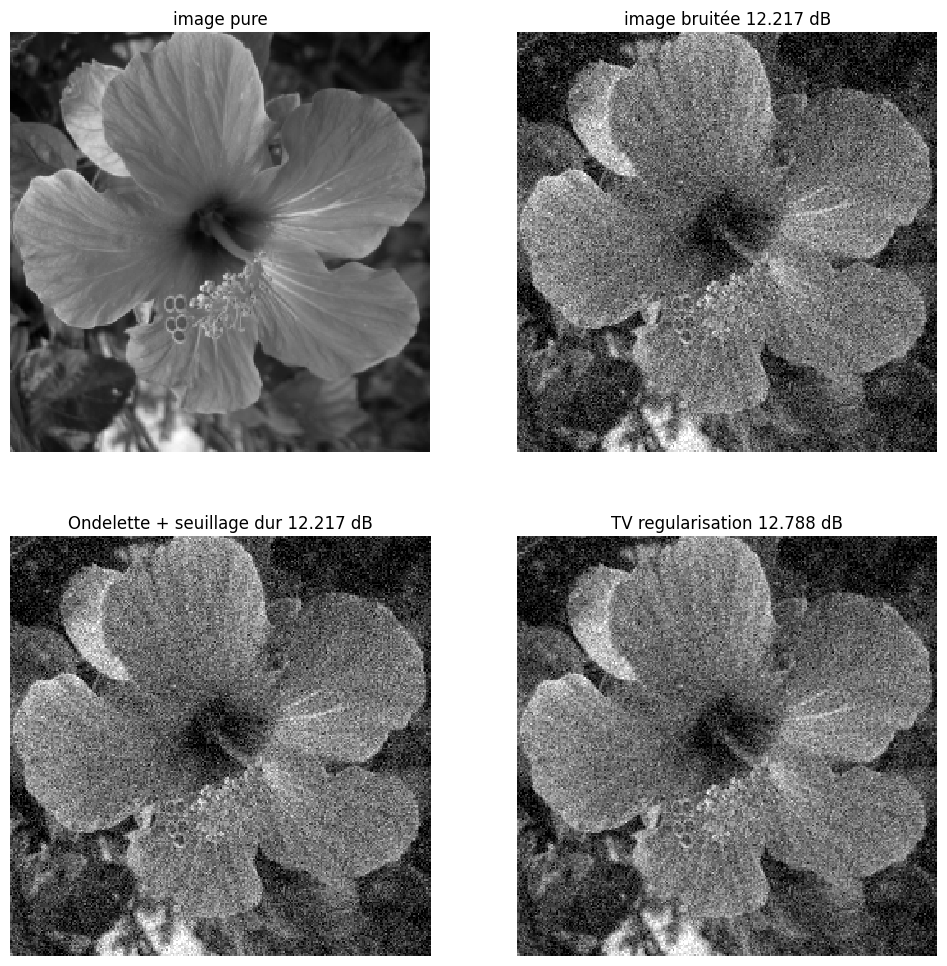

In [72]:
# y : image bruitée (float, normalisée entre 0 et 1)
f_wav = wavelet_hard_threshold_denoise(y,alpha=-.01,k=4)

enoisy = snr(f0, y)        # image bruitée 
esob   = snr(f0, f_wav)    # image TV regularisée 
esob1  = snr(f0, best_f)   # image régularisée ondelette + seuillage dur 

plt.figure(figsize=(12,12))

imageplot(clamp(f0), f"image pure", [2, 2, 1])
imageplot(clamp(y), f"image bruitée {enoisy:.3f} dB", [2, 2, 2])
imageplot(clamp(f_wav), f"Ondelette + seuillage dur {esob:.3f} dB", [2, 2, 3])
imageplot(clamp(best_f), f"TV regularisation {esob1:.3f} dB", [2, 2, 4])

`Débruitage TV (Total Variation)` 
Résoudre un problème de minimisation de type ROF, ou de minimisation avec pénalisation de la variation totale $||\nabla f||TV$
__effet attendu :__
   - lissage du bruit dans les régions quasi constantes,
   - conservation de bords nets, mais possible effet « escaliers » dans les zones à gradient doux.
   - seuillage dur dans un cadre serré d’ondelettes invariant par translation
`Seuillage dur dans un cadre serré d’ondelettes invariant par translation`
- appliquer une transformée en ondelettes redundante (non décimée / translation invariant tight frame).
- faire le seuillage dur, tous les $abs|coefficients| < seuil\text{, } T$ sont mis à zéro, les autres sont conservés inchangés. 
- puis reconstruire l’image.

__effet attendu :__
  - bonne suppression du bruit gaussien,
  - meilleure préservation des détails et textures fines qu’un TV trop fort,
  - la redondance / invariance par translation réduit les artefacts pseudo‑Gibbs.

## _`Schéma fléché`_
$y \xrightarrow{\,W\,} w = W y \quad\xrightarrow{\,T_T\,}\quad \tilde{w} = T_T(w) \quad\xrightarrow{\,W^{-1}}\, \quad f = W^{-1} \tilde{w}.$
C’est exactement l’analogue « ondelettes » de ce que l'on fait en TV :

 - Variation totale TV : $f=argmin_f \frac{1}{2} |f−y|^2+ \lambda||\nabla f||TV$.
 - Ondelette + seuil dur : $f=W^{−1}(T_T(W_y))$.

Le schéma l'on utilise (petits filtres + pseudo‑synthèse) n’est pas une vraie transformée ondelette multi‑échelle / frame serré : c’est plus un filtre passe‑haut + « remise » des détails, donc la capacité de débruitage est limitée.


#### `Analyse / synthèse orthogonale 1 niveau`

In [73]:
import pywt
import numpy as np

wavelet = 'db2'   # ou 'haar', 'db4', etc.

def dwt2_analysis(y):
    # y : image 2D (numpy array)
    cA, (cH, cV, cD) = pywt.dwt2(y, wavelet=wavelet, mode='symmetric')
    return cA, cH, cV, cD

def hard_thresh(w, T):
    return np.where(np.abs(w) < T, 0.0, w)

def dwt2_synthesis(cA, cH, cV, cD):
    coeffs = (cA, (cH, cV, cD))
    y_rec = pywt.idwt2(coeffs, wavelet=wavelet, mode='symmetric')
    return y_rec

#### `Denoising par seuillage dur « propre »`

In [75]:
def wavelet_denoise_orthogonal(y, k=1.0):
    rows, cols = y.shape
    N = rows * cols

    # analyse 1 niveau
    cA, cH, cV, cD = dwt2_analysis(y)
    # estimation sigma sur cD (détails diagonaux)
    mad = np.median(np.abs(cD - np.median(cD)))
    sigma = mad / 0.6745
    # seuil universel
    T = k * sigma * np.sqrt(2 * np.log(N))
    # seuillage dur des détails
    cH_t = hard_thresh(cH, T)
    cV_t = hard_thresh(cV, T)
    cD_t = hard_thresh(cD, T)
    # reconstruction orthogonale
    f_wav = dwt2_synthesis(cA, cH_t, cV_t, cD_t)
    return f_wav

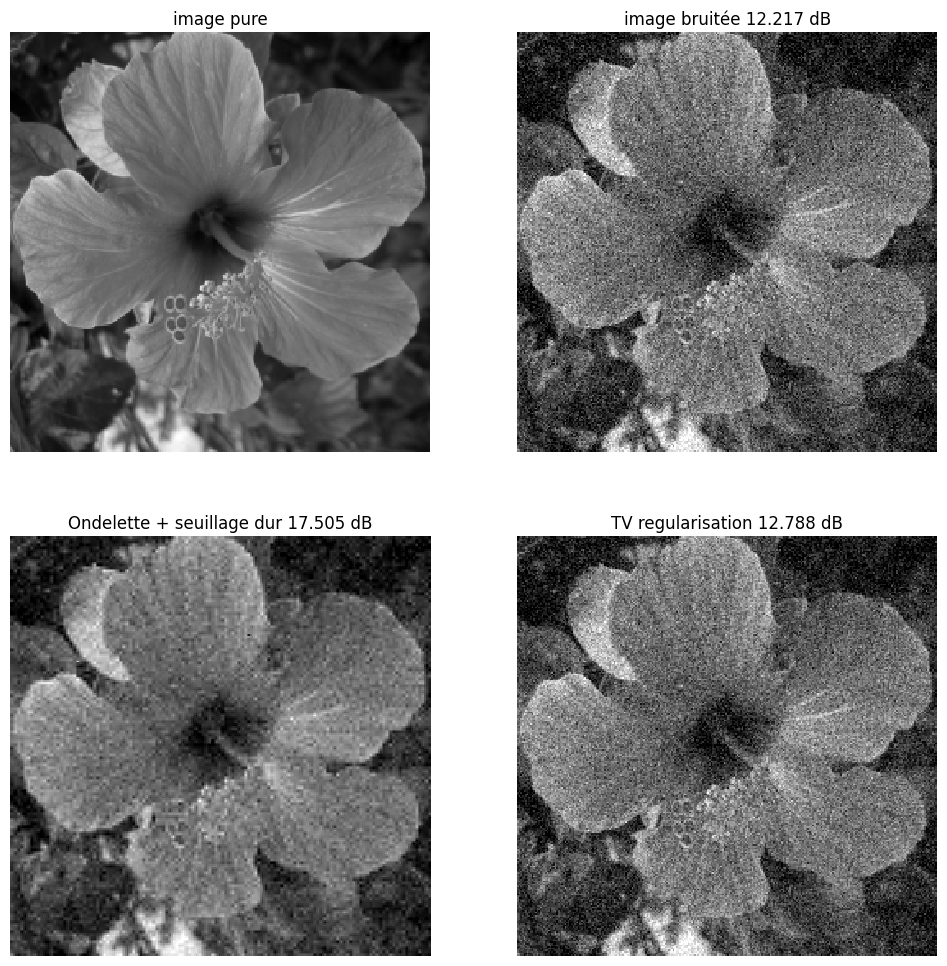

In [76]:
# y : ton image bruitée (float, normalisée entre 0 et 1)
f_wav = wavelet_denoise_orthogonal(y)

enoisy = snr(f0, y)  # image débruitée ondelelette + seuillage dur 
esob   = snr(f0, f_wav) # image TV regularisée 
esob1  = snr(f0, best_f) # image TV regularisée 
plt.figure(figsize=(12,12))

imageplot(clamp(f0), f"image pure", [2, 2, 1])
imageplot(clamp(y), f"image bruitée {enoisy:.3f} dB", [2, 2, 2])
imageplot(clamp(f_wav), f"Ondelette + seuillage dur {esob:.3f} dB", [2, 2, 3])
imageplot(clamp(best_f), f"TV regularisation {esob1:.3f} dB", [2, 2, 4])
# Ensuite tu compares f_wav avec fTV (ta solution TV) : PSNR, SSIM, visuel...

`Débruitage TV (Total Variation)` 
Résoudre un problème de minimisation de type ROF, ou de minimisation avec pénalisation de la variation totale $||\nabla f||TV$
__effet attendu :__
   - lissage du bruit dans les régions quasi constantes,
   - conservation de bords nets, mais possible effet « escaliers » dans les zones à gradient doux.
   - seuillage dur dans un cadre serré d’ondelettes invariant par translation
`Seuillage dur dans un cadre serré d’ondelettes invariant par translation`
- appliquer une transformée en ondelettes redundante (non décimée / translation invariant tight frame).
- faire le seuillage dur, tous les $abs|coefficients| < seuil\text{, } T$ sont mis à zéro, les autres sont conservés inchangés. 
- puis reconstruire l’image.

__effet attendu :__
  - bonne suppression du bruit gaussien,
  - meilleure préservation des détails et textures fines qu’un TV trop fort,
  - la redondance / invariance par translation réduit les artefacts pseudo‑Gibbs.